## Example of code

The following code was written by me for a practical application of data cleaning and management using Python, Visual Studio Code and GitHub. 

### Data

The data were given as a means of practice. Several datasets are to be cleaned and merged : four contain anthropometric data for different countries, and one contains information on the gene expression of groups of individuals. We suppose that we want to merge all datasets together in order to later analyze it.
The original data is found in the folder `Code project\data`, and the final dataset is placed in the folder `Code project\out`.

### The analysis

After the cleaning and merging, we briefly looked at the distribution of the variable Body Mass Index (BMI) in different populations, and at whether the BMI seems related to the expression of certain genes.

# Data preprocessing

### Import of the datasets

In [78]:
import pandas as pd
import numpy as np
NL= pd.read_csv("data/NL.csv")
PL = pd.read_csv("data/PL.csv")
UK = pd.read_csv("data/UK.csv")
US = pd.read_csv("data/US.csv")

In [79]:
genes = pd.read_csv("data/genes.csv")
genes

,id,source,geneA,geneB,geneC
0,NL_0590,NL,0.725787,10.516221,88.803319
1,NL_0395,NL,1.827190,-1.364823,100.720557
2,NL_0183,NL,2.701437,14.623456,89.894749
3,NL_0308,NL,1.729680,10.100416,99.305338
4,NL_0826,NL,0.470720,-3.894969,103.650732
...,...,...,...,...,...
3492,S1406,US,1.129991,8.910793,98.230566
3493,S1221,US,1.688210,7.187131,112.130364
3494,S1218,US,1.084599,-3.339440,121.564776
3495,S1306,US,27.838815,22.259590,93.332950


In [80]:
genes.source.value_counts()

source
PL    1339
NL    1322
GB     694
US     142
Name: count, dtype: int64

We see here that UK is coded as GB, which is a difference with the other dataset.

It seems to have worked, let's now look at the dataframes themselves.

In [81]:
NL

,id,weight,height,sex,smokes
0,NL_0001,105,188,male,yes
1,NL_0002,114,177,male,yes
2,NL_0003,70,176,female,no
3,NL_0004,68,175,male,no
4,NL_0005,86,186,male,yes
...,...,...,...,...,...
1317,NL_1318,48,168,female,no
1318,NL_1319,97,181,male,no
1319,NL_1320,96,185,male,no
1320,NL_1321,77,176,female,no


In [82]:
PL

,id,heigth,weight,sex,smokes
0,S0001,178.0,77.0,female,False
1,S0002,155.0,74.0,male,False
2,S0003,173.0,70.0,male,True
3,S0004,167.0,95.0,male,False
4,S0005,181.0,78.0,female,False
...,...,...,...,...,...
1533,S0537,158.0,56.0,male,False
1534,S0538,159.0,43.0,male,False
1535,S0539,162.0,80.0,male,False
1536,S053a,194.0,110.0,NaN,True


Here we see that height and weight are not in the same order as for the dataset NL. Also, height is not correctly written.
id is also specified differently, without a "_" in between the letter and the numbers. Moreover, id is sometimes written with lower cases letter, such as S053a and S053b.

In [83]:
UK

,id,weight,height,sex,smokes
0,UK_0001,180.8,-1.0,male,0
1,UK_0002,141.1,65.7,male,0
2,UK_0003,180.8,68.5,male,0
3,UK_0004,218.3,68.9,male,0
4,UK_0005,147.7,62.6,female,0
...,...,...,...,...,...
689,UK_0690,156.5,61.8,female,0
690,UK_0691,176.4,65.4,male,1
691,UK_0692,205.0,72.4,male,0
692,UK_0693,130.1,66.1,female,0


The columns are more similar to the first dataset, but we see an obvious outlier : the height of someone cannot be -1. We will need to check for unrealistic values or outliers. Smokes is in numeric values instead of yes/no values.

In [84]:
US

,id,weight,height,sex,smokes
0,S1272,61,NaN,female,no
1,S1288,105,NaN,female,no
2,S1361,92,NaN,female,no
3,S1091,78,182.0,male,no
4,S1351,83,NaN,female,no
...,...,...,...,...,...
456,S1300,61,NaN,female,no
457,S1169,112,179.0,male,no
458,S1048,96,172.0,male,yes
459,S1352,62,NaN,female,no


The same problem appears here in the inscription of id as for the PL dataset. We also see several NaN in the variable height, which we have to take into account.

In [85]:
PL.describe()

,heigth,weight
count,1472.000000,1494.000000
mean,169.404891,75.417001
std,9.580837,16.261988
min,146.000000,35.000000
25%,161.000000,65.000000
50%,168.000000,72.000000
75%,176.000000,86.000000
max,202.000000,149.000000


In [86]:
US.describe()

,weight,height
count,461.000000,226.000000
mean,81.754881,174.566372
std,16.541733,6.892026
min,40.000000,157.000000
25%,70.000000,170.000000
50%,81.000000,174.000000
75%,93.000000,179.000000
max,138.000000,198.000000


In [87]:
NL.describe()

,weight,height
count,1322.000000,1322.000000
mean,80.231467,177.176248
std,16.460242,9.276962
min,35.000000,153.000000
25%,69.000000,170.000000
50%,79.500000,176.500000
75%,91.750000,184.000000
max,142.000000,207.000000


In [88]:
UK.describe()

,weight,height,smokes
count,694.000000,694.000000,694.000000
mean,273.200865,64.406484,0.145533
std,264.109384,14.566331,0.352892
min,61.700000,-1.000000,0.000000
25%,158.700000,64.600000,0.000000
50%,185.200000,67.300000,0.000000
75%,211.600000,69.700000,0.000000
max,999.000000,78.000000,1.000000


The values obtained with UK are very unlikely. -1 is not an acceptable height, and 999 is not a possible weight. Also, 78cm seems to be small for a maximum height, and the median weight (185.2) seems to be very high. This could lead us to think that some values should be set as NaN (999 and -1) and that the columns have been written with swapped labels. A median height of 185 makes more sense than a median weight of the same value, and vice versa for the median weight of 67.3. Another possibility would be that the weight is in pounds instead of kg and that the height is in inches. An inch is equal to 2.54cm.

### Modification of the datasets

Let's start by modifying the headers of the columns for the dataset PL.

In [89]:
PL = PL.rename(columns = {'heigth':'height'})
newOrder = ['id','weight','height','sex','smokes']
PL = PL.reindex(columns = newOrder)
PL

,id,weight,height,sex,smokes
0,S0001,77.0,178.0,female,False
1,S0002,74.0,155.0,male,False
2,S0003,70.0,173.0,male,True
3,S0004,95.0,167.0,male,False
4,S0005,78.0,181.0,female,False
...,...,...,...,...,...
1533,S0537,56.0,158.0,male,False
1534,S0538,43.0,159.0,male,False
1535,S0539,80.0,162.0,male,False
1536,S053a,110.0,194.0,NaN,True


In [90]:
UK.height*2.54

0       -2.540
1      166.878
2      173.990
3      175.006
4      159.004
        ...   
689    156.972
690    166.116
691    183.896
692    167.894
693    161.036
Name: height, Length: 694, dtype: float64

In [91]:
UK.weight/2.204

0      82.032668
1      64.019964
2      82.032668
3      99.047187
4      67.014519
         ...    
689    71.007260
690    80.036298
691    93.012704
692    59.029038
693    51.996370
Name: weight, Length: 694, dtype: float64

It all makes more sense. The weight was probably measured in pound and the height in inch.

In [92]:
UK.loc[(UK.height == -1), 'height']= None
UK.height.describe()

count    663.000000
mean      67.464706
std        3.523819
min       58.300000
25%       65.000000
50%       67.700000
75%       70.100000
max       78.000000
Name: height, dtype: float64

In [93]:
UK.loc[(UK.weight == 999), 'weight']= None
UK.weight.describe()

count    614.000000
mean     178.634202
std       33.929618
min       61.700000
25%      156.500000
50%      180.800000
75%      200.600000
max      284.400000
Name: weight, dtype: float64

In [94]:
UK.height = UK.height*2.54
UK.height.describe()

count    663.000000
mean     171.360353
std        8.950501
min      148.082000
25%      165.100000
50%      171.958000
75%      178.054000
max      198.120000
Name: height, dtype: float64

In [95]:
UK.weight = UK.weight/2.204
UK.weight.describe()

count    614.000000
mean      81.050001
std       15.394563
min       27.994555
25%       71.007260
50%       82.032668
75%       91.016334
max      129.038113
Name: weight, dtype: float64

Let's now check that sex has only two possible values, and is not coded in another way.

In [96]:
PL.sex.value_counts() # 2 values female and male
US.sex.value_counts() # same
NL.sex.value_counts() # same
UK.sex.value_counts() 

sex
male      424
female    173
Male       45
FEMALE     17
MALE       14
Female     13
Woman       8
Name: count, dtype: int64

In the UK dataset, the variable sex is not well coded. Let's set all values to either female or male.

In [97]:
UK.loc[(UK.sex == 'Male'),'sex'] = "male"
UK.loc[(UK.sex == 'MALE'), 'sex'] = "male"
UK.loc[(UK.sex == 'FEMALE'), 'sex'] = "female"
UK.loc[(UK.sex == 'Female'), 'sex'] = "female"
UK.loc[(UK.sex == 'Woman'), 'sex'] = "female"

Now that the columns height and weight are correctly set, we can focus on the smokes variable for all datasets. We will set all 0 and False to "no", and all 1 and True to "yes". 

In the UK dataset, values are divided in 0 and 1. In the PL one, smokes values are True or False.

In [98]:
UK.loc[(UK.smokes == 1),'smokes'] = "yes"
UK.loc[(UK.smokes == 0), 'smokes'] = "no"
PL.loc[(PL.smokes == True),'smokes'] = "yes"
PL.loc[(PL.smokes == False), 'smokes'] = "no"
PL.smokes, UK.smokes

C:\Users\milam\AppData\Local\Temp\ipykernel_15496\4280050162.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'yes' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  UK.loc[(UK.smokes == 1),'smokes'] = "yes"


(0        no
 1        no
 2       yes
 3        no
 4        no
        ... 
 1533     no
 1534     no
 1535     no
 1536    yes
 1537     no
 Name: smokes, Length: 1538, dtype: object,
 0       no
 1       no
 2       no
 3       no
 4       no
       ... 
 689     no
 690    yes
 691     no
 692     no
 693     no
 Name: smokes, Length: 694, dtype: object)

We now want to check whether or not we have duplicated rows, or duplicated id values in each dataset, and among the datasets.

In [99]:
NL.id.duplicated().sum() # no duplicates
UK.id.duplicated().sum() # no duplicates
US.id.duplicated().sum() # no duplicates
PL.id.duplicated().sum() # 199 duplicates

np.int64(199)

In [100]:
PL.loc[PL.id.duplicated()]

,id,weight,height,sex,smokes
783,S030f,65.0,161.0,male,no
784,S030f,65.0,161.0,male,no
785,S030f,65.0,161.0,male,no
786,S030f,65.0,161.0,male,no
787,S030f,65.0,161.0,male,no
...,...,...,...,...,...
977,S030f,65.0,161.0,male,no
978,S030f,65.0,161.0,male,no
979,S030f,65.0,161.0,male,no
980,S030f,65.0,161.0,male,no


The same line is repeated 199 times in PL. We only want to keep one line.

In [101]:
len(PL.id)-199

1339

In [102]:
PL = PL.drop_duplicates()
len(PL.id)

1339

However, merging will later be a problem using concat() with PL if the index is not reset, as concat() bases its merging on the index of the two dataframes merged. 
I have to reset the values of index for PL. The function reset_index can be used, with the argument drop=True indicating that the previous index values should not be kept, and inplace=True indicating that the change of index values must be done on the original dataframe.

In [103]:
PL.reset_index(drop=True, inplace=True)

We cleaned the PL dataset. Let's no look at whether or not the id are different between PL and US.

In [104]:
sum([i in PL.id for i in UK.id])

0

It looks like they are. For extra security, I will still create another variable source that insures that the rows cannot be mistaken between US and PL when joining genes and anthropo. The key to merge the final anthropometric dataset with genes will then be (id, source).

In [105]:
new_colNL = pd.DataFrame({'source':["NL"]*len(NL.id)})
new_colPL = pd.DataFrame({'source':["PL"]*len(PL.id)})
new_colUK = pd.DataFrame({'source':["GB"]*len(UK.id)})
new_colUS = pd.DataFrame({'source':["US"]*len(US.id)})

In [106]:
NL = pd.concat([NL, new_colNL], axis=1)
PL = pd.concat([PL, new_colPL], axis=1)
UK = pd.concat([UK, new_colUK], axis=1)
US = pd.concat([US, new_colUS], axis=1)

## Merging of the datasets

We can now merge the 4 datasets together.

In [107]:
anthropo = pd.concat([NL,PL,UK,US], axis=0)
anthropo.describe()

,weight,height
count,3692.000000,3484.000000
mean,79.430580,173.540733
std,16.553971,9.692080
min,27.994555,146.000000
25%,68.000000,166.878000
50%,79.000000,173.000000
75%,91.000000,180.000000
max,149.000000,207.000000


In [108]:
len(anthropo.id)

3816

In [109]:
len(NL.id)+len(PL.id)+len(UK.id)+len(US.id)

3816

Good. We now want to merge anthropo and genes. Genes has fewer rows than anthropo, therefore some individuals present in anthropo might be missing in genes. Thus, I will apply a left join from genes to anthropo.

In [110]:
combined_dataset = genes.merge(anthropo, how= 'right', on=['id','source'])
combined_dataset

,id,source,geneA,geneB,geneC,weight,height,sex,smokes
0,NL_0001,NL,2.852573,15.139682,88.698757,105.0,188.0,male,yes
1,NL_0002,NL,23.406720,23.477106,105.267242,114.0,177.0,male,yes
2,NL_0003,NL,0.375769,-6.081572,99.667734,70.0,176.0,female,no
3,NL_0004,NL,0.800761,-10.197789,82.935411,68.0,175.0,male,no
4,NL_0005,NL,1.008053,2.101691,97.957148,86.0,186.0,male,yes
...,...,...,...,...,...,...,...,...,...
3811,S1300,US,NaN,NaN,NaN,61.0,NaN,female,no
3812,S1169,US,NaN,NaN,NaN,112.0,179.0,male,no
3813,S1048,US,NaN,NaN,NaN,96.0,172.0,male,yes
3814,S1352,US,NaN,NaN,NaN,62.0,NaN,female,no


In [111]:
anthropo.shape

(3816, 6)

The number of rows are matching between genes and our final_df. There should have been no error in joining the datasets by keys.

I will now export the dataframe with all modifications in the file out.

In [ ]:
combined_dataset.to_csv("out/combined_dataset.csv", index=False)

## Missing values

In [113]:
combined_dataset.isna().sum()

id          0
source      0
geneA     324
geneB     324
geneC     324
weight    124
height    332
sex        34
smokes    104
dtype: int64

The counts for NAs are high for the variables given in the anthropometric dataset. It is interesting to investigate further the missing values looking at their presence for each country dataset.
Regarding the missing data for geneA, geneB and geneC, it is due to the merging, as more observations were included in the anthropo dataset than in the genes dataset. Some individuals that were part in the anthropometric study were not included in the genes dataset. 

In [114]:
NL.isna().sum()

id        0
weight    0
height    0
sex       0
smokes    0
source    0
dtype: int64

There is no missing value in the data collected from the Netherlands.

In [115]:
UK.isna().sum()

id         0
weight    80
height    31
sex        0
smokes     0
source     0
dtype: int64

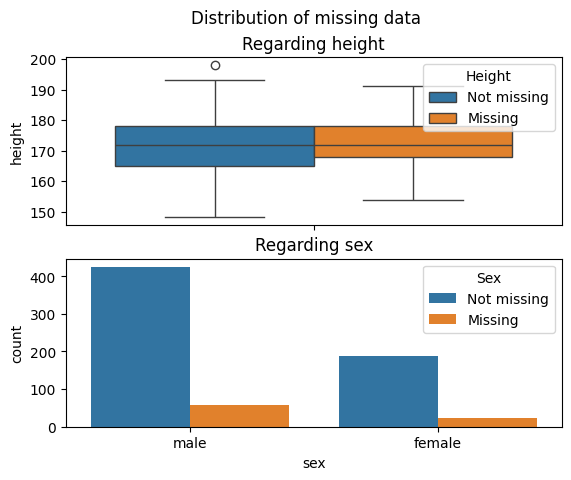

In [116]:
import seaborn as sns 
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,1)

fig.suptitle("Distribution of missing data")
axes[0].set_title("Regarding height")
axes[1].set_title("Regarding sex")
naUK= pd.isna(UK.weight)
ax = sns.boxplot(UK,y="height", hue=naUK, ax=axes[0])
ax.legend(title='Height', labels=['Not missing', 'Missing'])
ax2 = sns.countplot(data=UK,x='sex', hue=naUK, ax=axes[1])
ax2.legend(title = 'Sex', labels=['Not missing', 'Missing'])

Looking at both plots, the missing data doesn't seem to depend on collected variables. The NAs could be missing completely at random or missing not at random. 

In [117]:
US.isna().sum()

id          0
weight      0
height    235
sex         0
smokes      0
source      0
dtype: int64

In [118]:
US.weight.count()

np.int64(461)

The amount of missing values for the variable weight of the US dataset is large (235 out of 461, so around half of the data). As BMI is computed with height, this could lead to a biased estimation of the relationship between the BMI and the genes for people from the United States. Further analysis should be done in order to determine whether the data is missing completely at random.

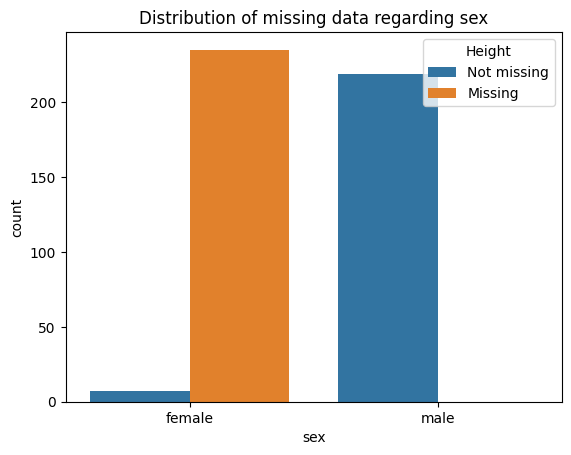

In [119]:
naUS = pd.isna(US.height)
ax = sns.countplot(data=US,x='sex', hue=naUS)
ax.set_title("Distribution of missing data regarding sex")
ax.legend(title='Height', labels=['Not missing', 'Missing'])

Based on the plot, the missing values seem to depend on sex. No value for male is missing but the values missing for female are way more numerous than the given values for women. Therefore, the data is missing at random, depending on known variables.

In [120]:
PL.isna().sum()

id          0
weight     44
height     66
sex        34
smokes    104
source      0
dtype: int64

The amount of missing values throughout the dataset of Poland is medium, knowing that it contains 1339 observations. However, the variable BMI computed later may have more missing values, in the case where weight and height are missing for different persons.

# Data Analysis

In [121]:
import seaborn as sns 
import matplotlib.pyplot as plt

## Distribution of BMI over source, sex and smokes

As we want to analyze the BMI, it may be useful to add a column computing the BMI of each individual. The BMI is computed with the formula weight(kg)/height(m)^2. In the dataset, the height is in cm.

In [122]:
BMI = pd.DataFrame({"BMI": combined_dataset.weight/(combined_dataset.height*0.01)**2})
BMI

,BMI
0,29.708013
1,36.388011
2,22.598140
3,22.204082
4,24.858365
...,...
3811,NaN
3812,34.955214
3813,32.449973
3814,NaN


In [123]:
final_df = pd.concat([combined_dataset, BMI], axis=1)
final_df

,id,source,geneA,geneB,geneC,weight,height,sex,smokes,BMI
0,NL_0001,NL,2.852573,15.139682,88.698757,105.0,188.0,male,yes,29.708013
1,NL_0002,NL,23.406720,23.477106,105.267242,114.0,177.0,male,yes,36.388011
2,NL_0003,NL,0.375769,-6.081572,99.667734,70.0,176.0,female,no,22.598140
3,NL_0004,NL,0.800761,-10.197789,82.935411,68.0,175.0,male,no,22.204082
4,NL_0005,NL,1.008053,2.101691,97.957148,86.0,186.0,male,yes,24.858365
...,...,...,...,...,...,...,...,...,...,...
3811,S1300,US,NaN,NaN,NaN,61.0,NaN,female,no,NaN
3812,S1169,US,NaN,NaN,NaN,112.0,179.0,male,no,34.955214
3813,S1048,US,NaN,NaN,NaN,96.0,172.0,male,yes,32.449973
3814,S1352,US,NaN,NaN,NaN,62.0,NaN,female,no,NaN


I can now use the variable BMI itself for the following analysis.

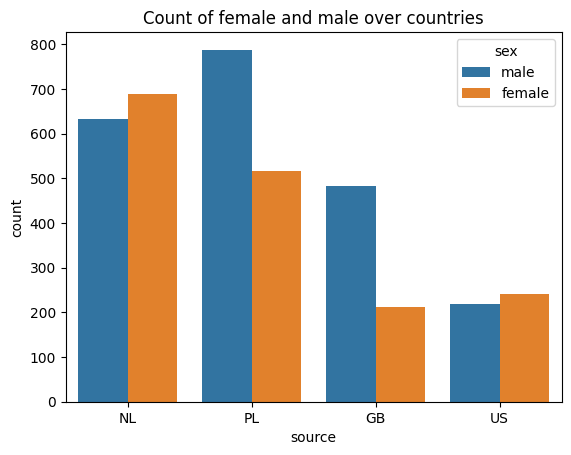

In [124]:
ax = sns.countplot(data=final_df, x='source', hue='sex').set_title("Count of female and male over countries")

In the further interpretations, it should be taken into account that the number of men investigated in Poland is high compared to the number of women. The data could be biased by an unrepresentative distribution of sex. Nevertheless, the large number of observations could compensate for that bias. A similar observation can be made regarding the United Kingdom.

Text(0.5, 1.0, 'Density of BMI based on sex')

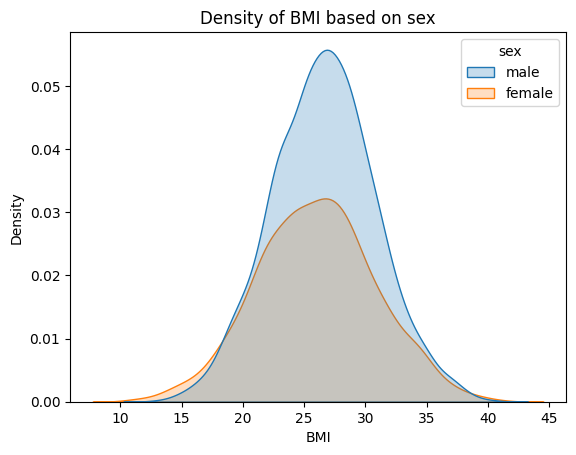

In [125]:
ax = sns.kdeplot(data=final_df,x='BMI', hue='sex', fill=True)
ax.set_title('Density of BMI based on sex')

The distribution of BMI depends on the sex of the individuals in this dataset.

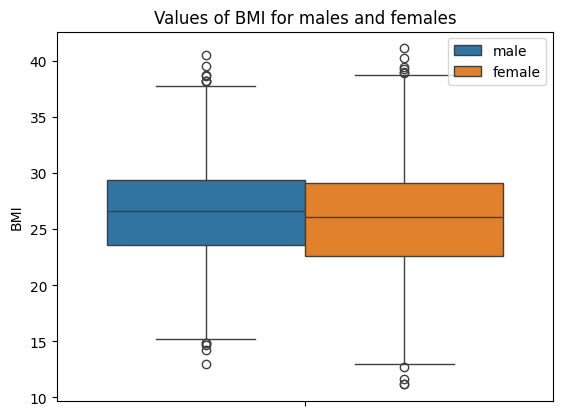

In [126]:
sns.boxplot(data=final_df,y='BMI', hue='sex').set_title("Values of BMI for males and females")
plt.legend(loc='upper right')

However, similar values of BMI are taken by men and women. The variance of the BMI is larger for women than for men, but the average BMI is around 26 for both.

Text(0.5, 1.0, 'Values of BMI depending on countries')

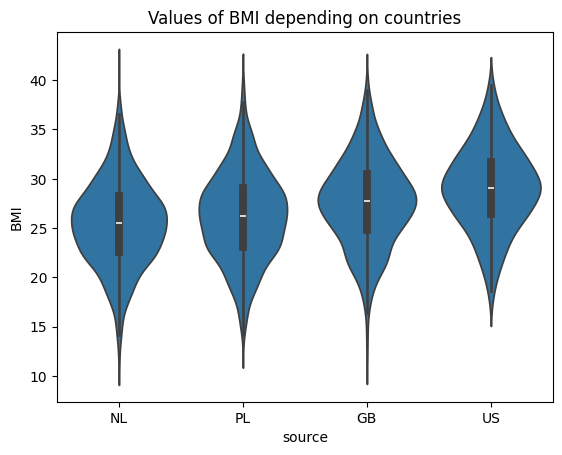

In [127]:
sns.violinplot(data=final_df, y='BMI', x='source').set_title('Values of BMI depending on countries')

The mean BMI differs slightly between countries. In the USA, the average BMI is higher than in the Netherlands or Poland. The distribution of the values of BMI is centered around the mean for each country.

Text(0.5, 1.0, 'Count of smokers over countries')

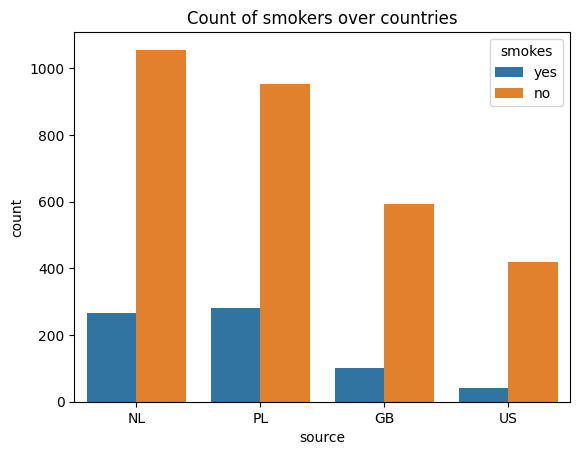

In [128]:
sns.countplot(data=final_df, x='source', hue='smokes').set_title("Count of smokers over countries")

Similar proportion of smokers are observed in the different countries. This proportion is slightly higher in Poland than in other countries.

Text(0.5, 1.0, 'Values of BMI depending on the smoking status')

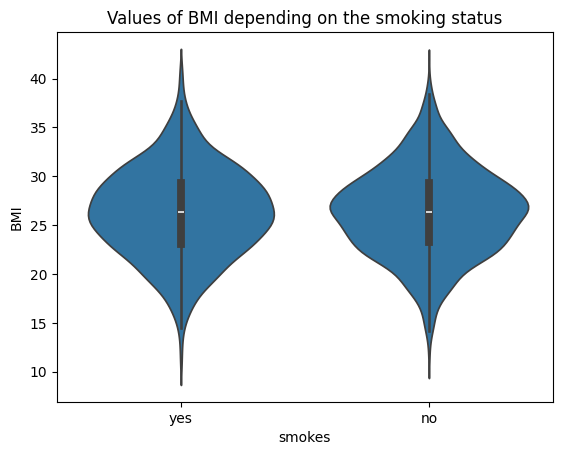

In [129]:
sns.violinplot(data=final_df, y='BMI', x='smokes').set_title('Values of BMI depending on the smoking status')

There is no significative differences for BMI values between those who smoke and those who do not.

## Analysis of BMI with gene

### Relationships over all countries

Text(0.5, 1.0, 'Relationship between BMI and geneA depending on the country')

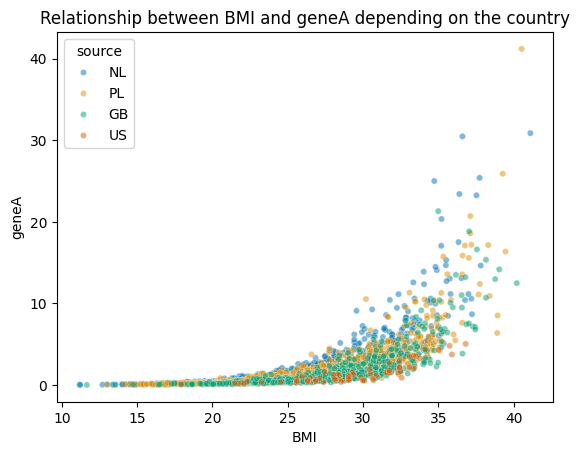

In [130]:
ax = sns.scatterplot(final_df, x='BMI', y='geneA', hue='source', palette='colorblind', s=20, alpha=0.5)
ax.set_title('Relationship between BMI and geneA depending on the country')

Looking at the latter plot, the distribution of BMI regarding gene A seems to follow the same pattern for each country. The relationship between BMI and gene A over all four countries seem to be of an exponential form.
I will now observe the relationship between gene B and BMI.

Text(0.5, 1.0, 'Relationship between BMI and geneB depending on the country')

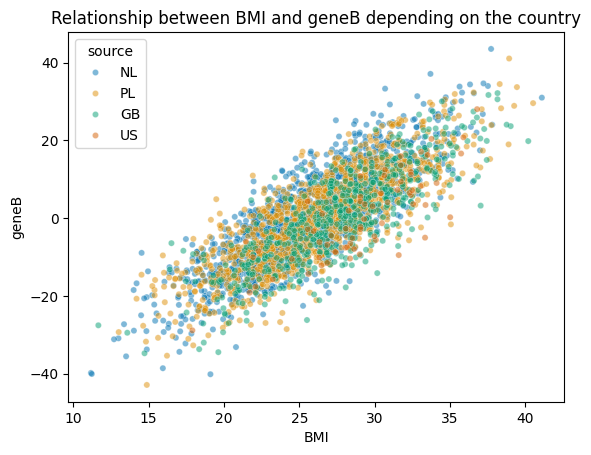

In [131]:
ax2 = sns.scatterplot(final_df, x='BMI', y='geneB', hue='source', palette='colorblind', s=20, alpha=0.5)
ax2.set_title('Relationship between BMI and geneB depending on the country')

Here, the relationship would be described by the linear family instead of the exponential one. The trend is indeed positive and linear, and the correlation between the two variables should be high (> 0.7).

Text(0.5, 1.0, 'Relationship between BMI and gene C depending on the country')

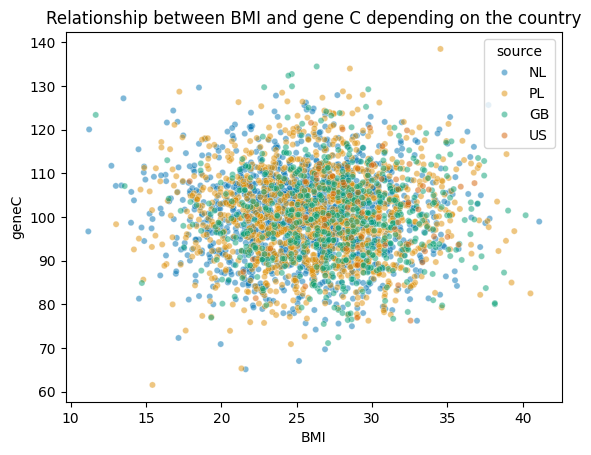

In [132]:
ax3 = sns.scatterplot(final_df, x='BMI', y='geneC', hue='source', palette='colorblind', s=20, alpha=0.5)
ax3.set_title('Relationship between BMI and gene C depending on the country')

There seems to be no significant relationship between the presence of gene C and the BMI. The points of the plot form a cloud with no specific increasing or decreasing tendency. Each color also forms a widely spread cloud with no apparent pattern. There should be no correlation between gene C and BMI, even on a country scale.

### Correlation and distributions
In order to confirm the plot analysis, I compute the correlations between all the numeric variables of the dataset. I expect BMI and weight to be highly correlation, as one is a linear transformation of the other. For BMI and height, the correlation should be lower, as the relationship is far from linear.

<Axes: >

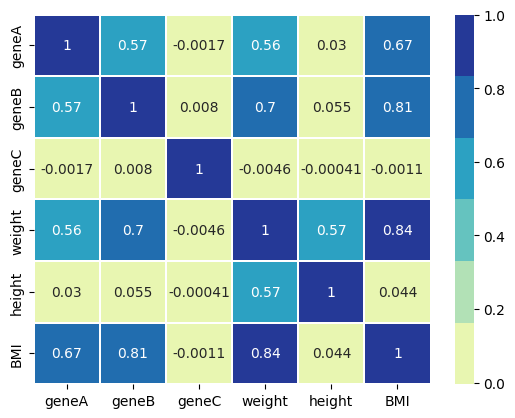

In [133]:
sns.heatmap(final_df.select_dtypes(include= np.number).corr(), annot=True, linewidth=0.01, cmap=sns.color_palette('YlGnBu'))

There is a strong correlation between gene B and the BMI (R=0.81), which can also be seen in the plots of BMI vs geneB, as a positive linear trend. Regarding gene C and BMI, the correlation is indeed almost equal to 0, meaning that there is no significant correlation between them. Finally, the relationship between BMI and geneA is lower than the one with geneB, but it can mostly be because the it is not linear and the correlation is computed over linear links.

Text(0.5, 1.05, 'Scatterplots and histograms for numeric variables')

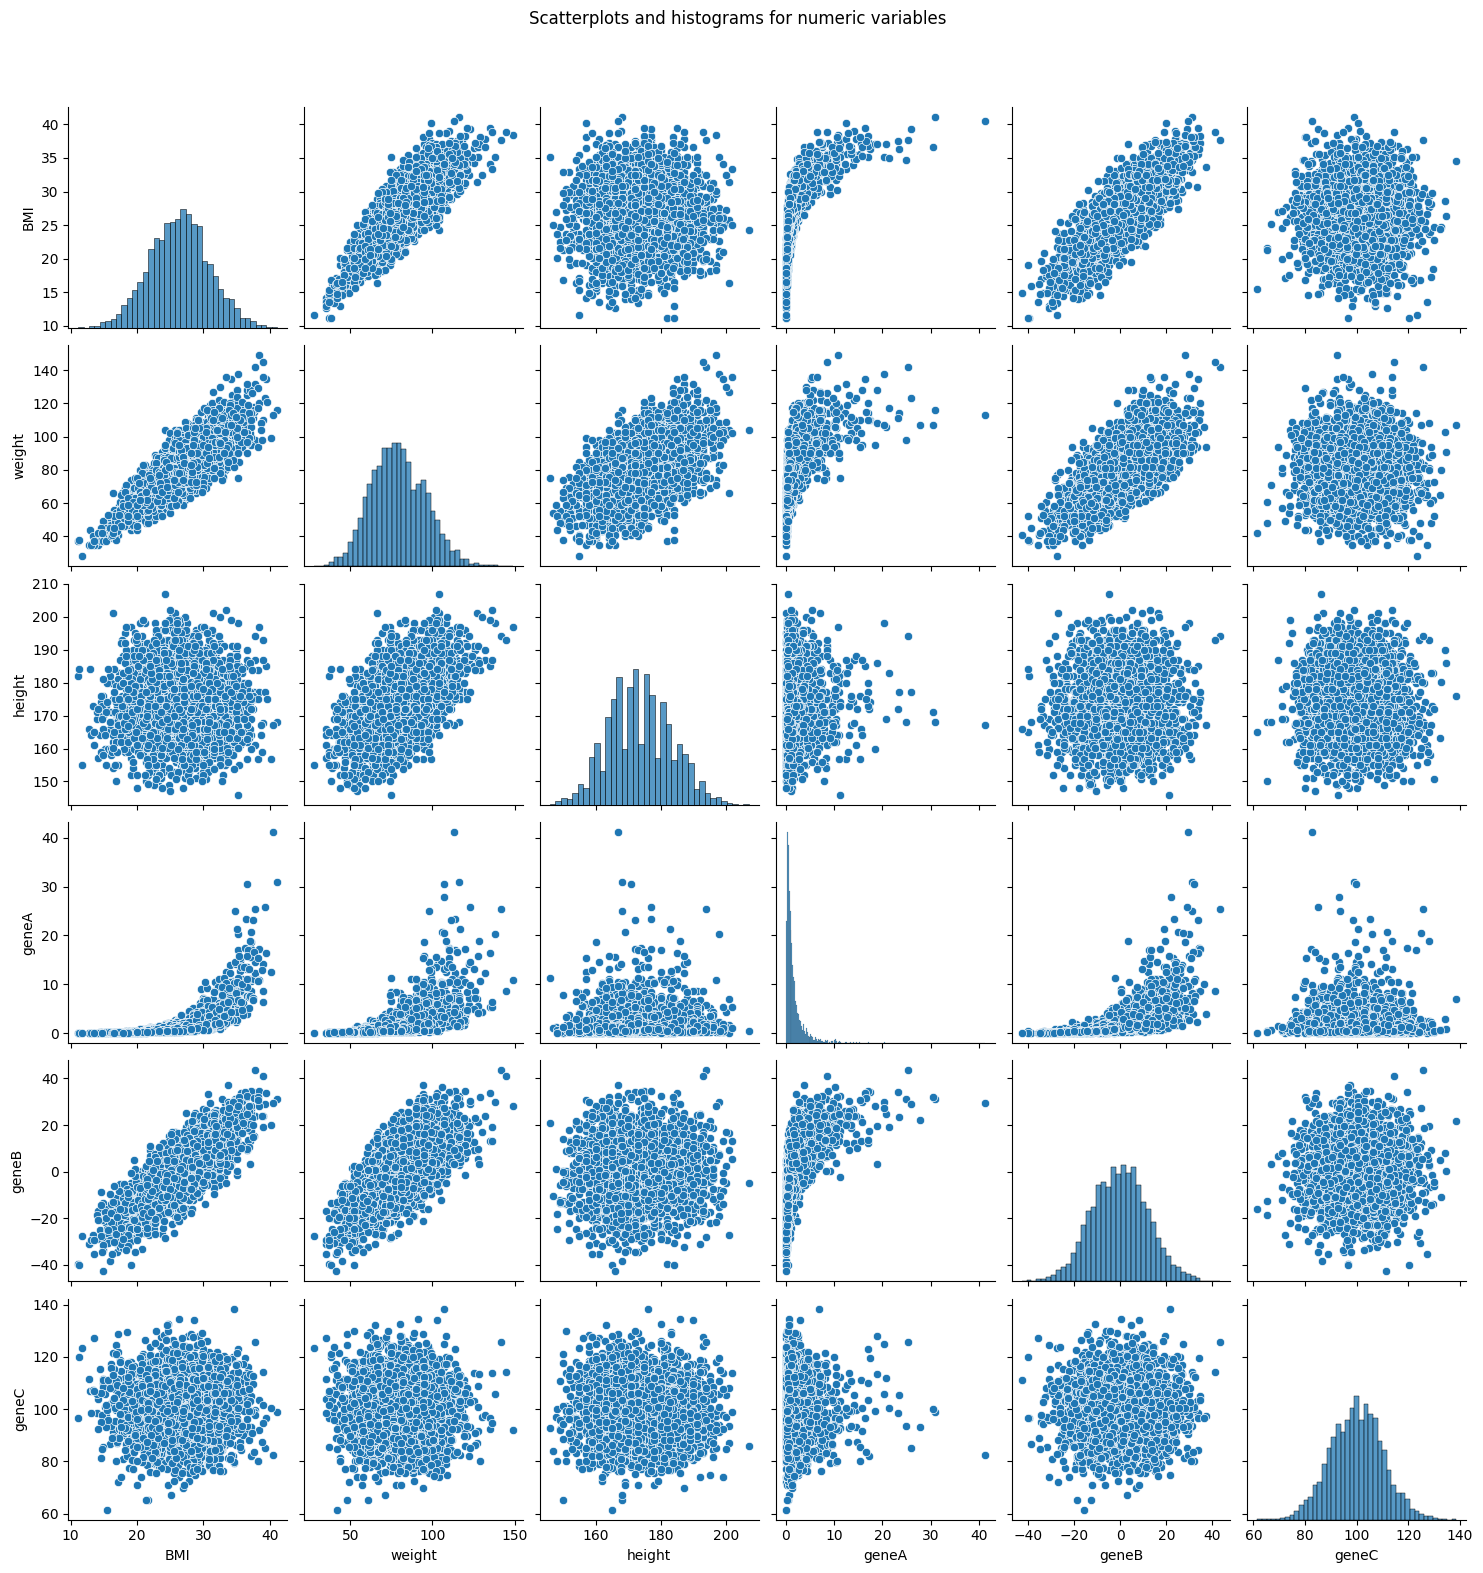

In [134]:
sns.pairplot(final_df[['BMI', 'weight', 'height','geneA','geneB','geneC']])
plt.suptitle("Scatterplots and histograms for numeric variables", y=1.05)

The distributions of all the variables except geneA seem to be close to normal. Indeed, the histograms of the values of each variables show a symmetry of the distribution and more frequent values around the mean or median. However, the distribution of geneA is far from normal, as a very large part of the population investigated has small values for geneA. Weight also seems to have a linear relationship with gene B.

### Variations of the relationship based on other variables

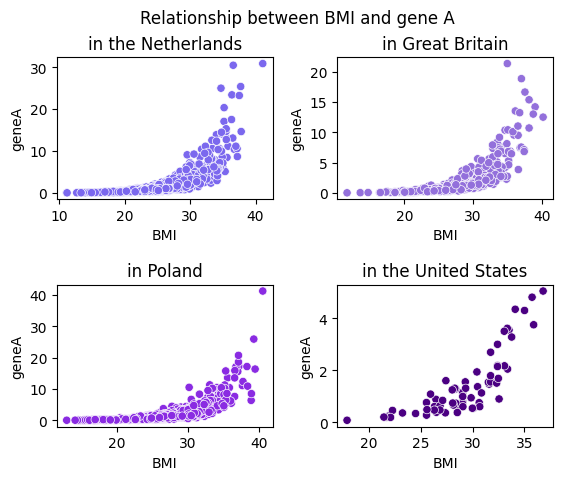

In [135]:
fig, axes = plt.subplots(2,2)

fig.suptitle("Relationship between BMI and gene A")
axes[0,0].set_title("in the Netherlands")
axes[0,1].set_title("in Great Britain")
axes[1,0].set_title("in Poland")
axes[1,1].set_title("in the United States")

sns.scatterplot(data=final_df[final_df.source=="NL"],x='BMI', y="geneA",hue='source', ax=axes[0,0], palette=['mediumslateblue'], legend=False)
sns.scatterplot(data=final_df[final_df.source=="GB"],x='BMI', y="geneA", ax=axes[0,1], hue='source', legend=False, palette=['mediumpurple'])
sns.scatterplot(data=final_df[final_df.source=="PL"],x='BMI',y="geneA", ax=axes[1,0], hue='source', legend=False, palette=['blueviolet'])
sns.scatterplot(data=final_df[final_df.source=="US"],x='BMI',y="geneA", ax=axes[1,1], hue='source',legend=False, palette=['indigo'])

fig.subplots_adjust(hspace=.6, wspace=.3)

Looking at the variations of the relationship between gene A and BMi based on the home country of the participants, it seems that there is no major differences between the population of the four countries. The curve formed in the United States is slightly different from the others, but it could be due to the important amount of missing data. However, the values taken by the variable gene A in the US are very low compared to in other countries. As values are mostly missing for women, it could be due to the fact that women often have higher values of geneA than men.

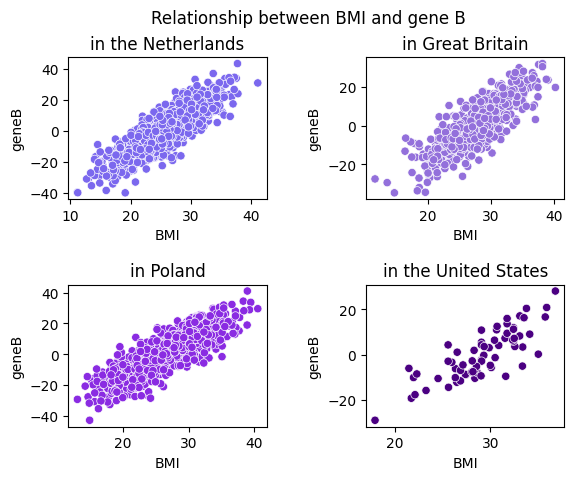

In [136]:
fig, axes = plt.subplots(2,2)

fig.suptitle("Relationship between BMI and gene B")
axes[0,0].set_title("in the Netherlands")
axes[0,1].set_title("in Great Britain")
axes[1,0].set_title("in Poland")
axes[1,1].set_title("in the United States")

sns.scatterplot(data=final_df[final_df.source=="NL"],x='BMI', y="geneB",hue='source', ax=axes[0,0], palette=['mediumslateblue'], legend=False)
sns.scatterplot(data=final_df[final_df.source=="GB"],x='BMI', y="geneB", ax=axes[0,1], hue='source', legend=False, palette=['mediumpurple'])
sns.scatterplot(data=final_df[final_df.source=="PL"],x='BMI',y="geneB", ax=axes[1,0], hue='source', legend=False, palette=['blueviolet'])
sns.scatterplot(data=final_df[final_df.source=="US"],x='BMI',y="geneB", ax=axes[1,1], hue='source',legend=False, palette=['indigo'])

# adjust horizontal space between plots see subplots_adjust for more options.
fig.subplots_adjust(hspace=.6, wspace=.5)

Even though the variance of gene B is lower in the United States (which could again be due to the lower number of observations and the high number of missing data), the relationship seems to follow the same regression line for all countries. All plots give values of geneB centered around 0 and included between 40 and -40, and similar values of BMI correspond to similar values of gene B. 

Text(0.5, 1.02, 'BMI against geneA for different combinations of sex and smokes')

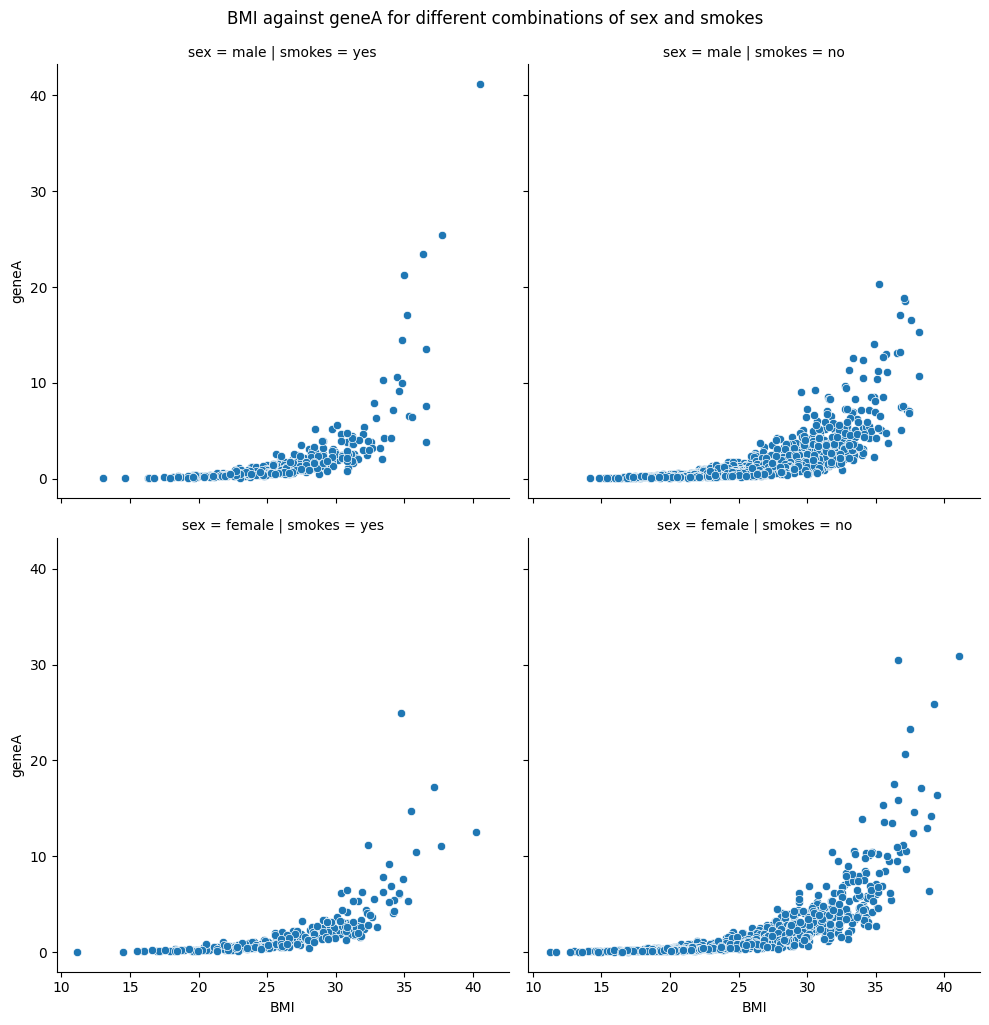

In [137]:
sns.relplot(final_df, x='BMI', y='geneA', row='sex', col='smokes')
plt.suptitle("BMI against geneA for different combinations of sex and smokes", y=1.02)

The gender and smoking status of the individuals don't seem to impact the relationship between BMI and gene A significantly. Contrary to what I assumed before, values of gene A are not particularly higher for women than for men. The differences in the plots regarding the USA should therefore only be related to a lack of observed data. However, to be certain of it, further analyses should be applied on a new dataset.

Text(0.5, 1.02, 'BMI against geneB for different combinations of sex and smokes')

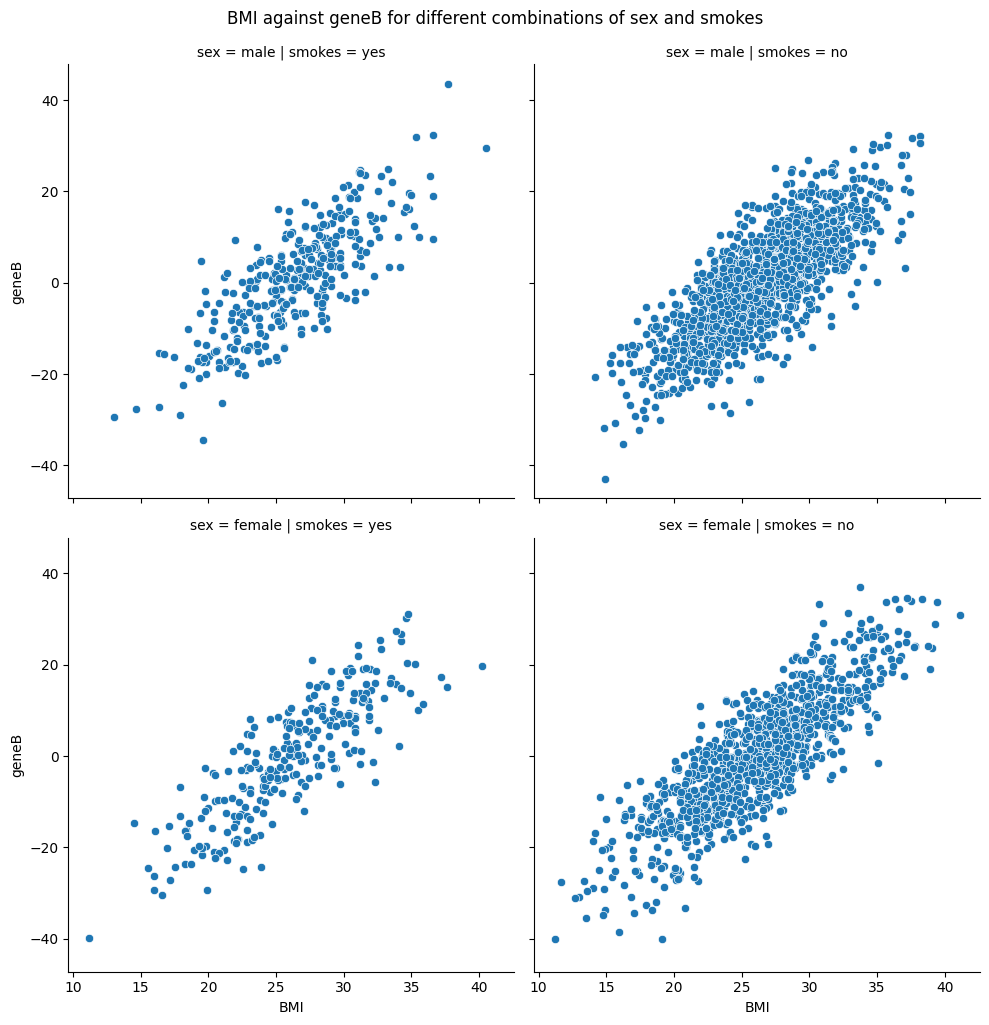

In [138]:
sns.relplot(final_df, x='BMI', y='geneB', row='sex', col='smokes')
plt.suptitle("BMI against geneB for different combinations of sex and smokes", y=1.02)

Here again, the relationship between gene B and BMI doesn't seem to be impacted by neither the gender nor the smoking status of the individuals. 

## Conclusion

Genes A and B should be performant predictors for the body mass indicator of people, no matter the country those people originate from. Even though the BMI also depends on sex, they are not major factors to include in these relationships. As BMI has a similar distribution than the normal one, a linear regression model could be implemented to predict values of BMI depending on values for genes A and B.